** Import pandas as pd.**

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

**Data Loading**

In [2]:
df= pd.read_csv('Salaries.csv')
print(df)

            Id       EmployeeName  \
0            1     NATHANIEL FORD   
1            2       GARY JIMENEZ   
2            3     ALBERT PARDINI   
3            4  CHRISTOPHER CHONG   
4            5    PATRICK GARDNER   
...        ...                ...   
148649  148650      Roy I Tillery   
148650  148651       Not provided   
148651  148652       Not provided   
148652  148653       Not provided   
148653  148654          Joe Lopez   

                                              JobTitle    BasePay  \
0       GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY  167411.18   
1                      CAPTAIN III (POLICE DEPARTMENT)  155966.02   
2                      CAPTAIN III (POLICE DEPARTMENT)  212739.13   
3                 WIRE ROPE CABLE MAINTENANCE MECHANIC   77916.00   
4         DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)  134401.60   
...                                                ...        ...   
148649                                       Custodian       0.00   
148

**Data Cleaning & Manipulation**

In [3]:
df.head(5)

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.00,400184.25,NaN,567595.43,567595.43,2011,NaN,San Francisco,NaN
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.28,538909.28,2011,NaN,San Francisco,NaN
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.60,NaN,335279.91,335279.91,2011,NaN,San Francisco,NaN
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.00,56120.71,198306.90,NaN,332343.61,332343.61,2011,NaN,San Francisco,NaN
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.60,9737.00,182234.59,NaN,326373.19,326373.19,2011,NaN,San Francisco,NaN


In [4]:
print(df.columns.tolist())

['Id', 'EmployeeName', 'JobTitle', 'BasePay', 'OvertimePay', 'OtherPay', 'Benefits', 'TotalPay', 'TotalPayBenefits', 'Year', 'Notes', 'Agency', 'Status']


In [5]:
 df['Status'].isna().sum()

148654

In [6]:
df.tail(5)

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
148649,148650,Roy I Tillery,Custodian,0.0,0.0,0.00,0.0,0.00,0.00,2014,NaN,San Francisco,NaN
148650,148651,Not provided,Not provided,NaN,NaN,NaN,NaN,0.00,0.00,2014,NaN,San Francisco,NaN
148651,148652,Not provided,Not provided,NaN,NaN,NaN,NaN,0.00,0.00,2014,NaN,San Francisco,NaN
148652,148653,Not provided,Not provided,NaN,NaN,NaN,NaN,0.00,0.00,2014,NaN,San Francisco,NaN
148653,148654,Joe Lopez,"Counselor, Log Cabin Ranch",0.0,0.0,-618.13,0.0,-618.13,-618.13,2014,NaN,San Francisco,NaN


In [7]:
print(df.isna().sum())

Id                       0
EmployeeName             0
JobTitle                 0
BasePay                609
OvertimePay              4
OtherPay                 4
Benefits             36163
TotalPay                 0
TotalPayBenefits         0
Year                     0
Notes               148654
Agency                   0
Status              148654
dtype: int64


In [8]:
df.shape

(148654, 13)

In [9]:
df = df.drop(columns=['Notes', 'Status'])

In [10]:
df['Benefits'].median()

28628.62

In [11]:
df['Benefits'] = df.groupby('JobTitle')['Benefits'].transform(lambda x: x.fillna(x.median()))


In [12]:
df['Benefits'] = df['Benefits'].fillna(0.0)

In [13]:
df['BasePay'] = df.groupby('JobTitle')['BasePay'].transform(lambda x: x.fillna(x.median()))



In [14]:

df['BasePay'] = df['BasePay'].fillna(0.0)

In [15]:
df['OvertimePay'] = df['OvertimePay'].fillna(0.0)

In [16]:
df['OtherPay'] = df['OtherPay'].fillna(0.0)

In [17]:
print(df.isna().sum())

Id                  0
EmployeeName        0
JobTitle            0
BasePay             0
OvertimePay         0
OtherPay            0
Benefits            0
TotalPay            0
TotalPayBenefits    0
Year                0
Agency              0
dtype: int64


** Use the .info() method to find out how many entries there are.**

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148654 entries, 0 to 148653
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Id                148654 non-null  int64  
 1   EmployeeName      148654 non-null  object 
 2   JobTitle          148654 non-null  object 
 3   BasePay           148654 non-null  float64
 4   OvertimePay       148654 non-null  float64
 5   OtherPay          148654 non-null  float64
 6   Benefits          148654 non-null  float64
 7   TotalPay          148654 non-null  float64
 8   TotalPayBenefits  148654 non-null  float64
 9   Year              148654 non-null  int64  
 10  Agency            148654 non-null  object 
dtypes: float64(6), int64(2), object(3)
memory usage: 12.5+ MB


In [29]:

df['JobTitle'] = df['JobTitle'].str.replace(r'\s+', ' ', regex=True).str.strip()


In [30]:
df['EmployeeName'] = df['EmployeeName'].str.replace(r'\s+', ' ', regex=True).str.strip()


In [31]:
df['Agency'] = df['Agency'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [32]:
print("Leading Spaces")
print(df[['EmployeeName','JobTitle','Agency']].apply(lambda x: x.str.startswith(' ').sum()))

print("\nTrailing Spaces")
print(df[['EmployeeName','JobTitle','Agency']].apply(lambda x: x.str.endswith(' ').sum()))

print("\nMultiple Spaces")
print(df[['EmployeeName','JobTitle','Agency']].apply(
    lambda x: x.str.contains(r'\s{2,}', regex=True, na=False).sum()
))

Leading Spaces
EmployeeName    0
JobTitle        0
Agency          0
dtype: int64

Trailing Spaces
EmployeeName    0
JobTitle        0
Agency          0
dtype: int64

Multiple Spaces
EmployeeName    0
JobTitle        0
Agency          0
dtype: int64


In [33]:
df['EmployeeName'] = df['EmployeeName'].astype(str).str.title()

In [34]:
df['JobTitle'] = df['JobTitle'].astype(str).str.title()

In [35]:
df.head(5)

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Agency
0,1,Nathaniel Ford,General Manager-Metropolitan Transit Authority,167411.18,0.00,400184.25,0.0,567595.43,567595.43,2011,San Francisco
1,2,Gary Jimenez,Captain Iii (Police Department),155966.02,245131.88,137811.38,0.0,538909.28,538909.28,2011,San Francisco
2,3,Albert Pardini,Captain Iii (Police Department),212739.13,106088.18,16452.60,0.0,335279.91,335279.91,2011,San Francisco
3,4,Christopher Chong,Wire Rope Cable Maintenance Mechanic,77916.00,56120.71,198306.90,0.0,332343.61,332343.61,2011,San Francisco
4,5,Patrick Gardner,"Deputy Chief Of Department,(Fire Department)",134401.60,9737.00,182234.59,0.0,326373.19,326373.19,2011,San Francisco


In [36]:

df['BasePay'] = df['BasePay'].clip(lower=0)
df['OvertimePay'] = df['OvertimePay'].clip(lower=0)
df['OtherPay'] = df['OtherPay'].clip(lower=0)
df['Benefits'] = df['Benefits'].clip(lower=0)


In [37]:

df['TotalPay'] = df['BasePay'] + df['OvertimePay'] + df['OtherPay']

df['TotalPayBenefits'] = df['TotalPay'] + df['Benefits']



In [38]:
df.describe()

,Id,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year
count,148654.000000,148654.000000,148654.000000,148654.000000,148654.000000,148654.000000,148654.000000,148654.000000
mean,74327.500000,66309.089786,5065.923568,3648.721474,18924.233233,75023.734828,93947.968061,2012.522643
std,42912.857795,42757.332647,11454.256594,8056.471027,17165.279060,50402.040354,62643.095404,1.117538
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2011.000000
25%,37164.250000,33599.432500,0.000000,0.000000,0.000000,36975.040000,45089.702500,2012.000000
50%,74327.500000,64983.605000,0.000000,811.170000,23214.020000,71590.405000,92550.275000,2013.000000
75%,111490.750000,94691.020000,4657.632500,4235.907500,33468.980000,105968.607500,132922.610000,2014.000000
max,148654.000000,319275.010000,245131.880000,400184.250000,96570.660000,567595.430000,567595.430000,2014.000000


****Exploratory Data Analysis 📈📈****

*What is the average Base Pay of all employees?*

In [39]:
df['BasePay'].mean().round(2)

66309.09

*Which are the top 5 highest-paying job titles?*

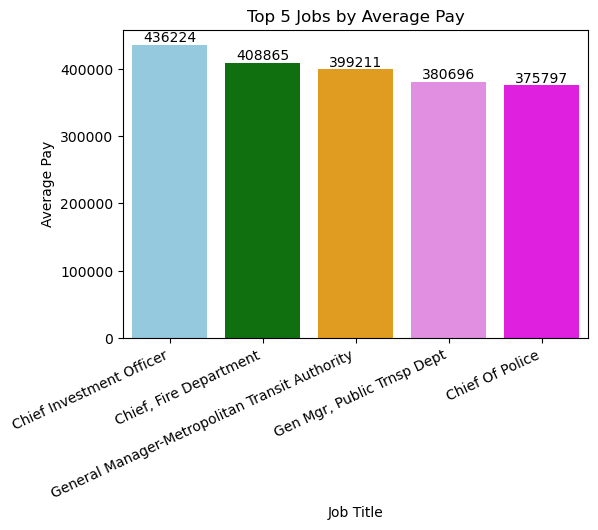

In [40]:
m=(df.groupby('JobTitle')['TotalPayBenefits'].mean().sort_values(ascending=False).head(5)).reset_index()  

plt.figure(figsize=(6,4))

colors = ["skyblue", "green", "orange", "violet","magenta"]

ax=sns.barplot(x='JobTitle', y='TotalPayBenefits', data=m, hue='JobTitle', palette=colors)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
    
plt.xticks(rotation=25, ha='right')
plt.title('Top 5 Jobs by Average Pay')
plt.xlabel('Job Title')
plt.ylabel('Average Pay')

plt.show()

*Which job titles receive the highest overtime pay?*

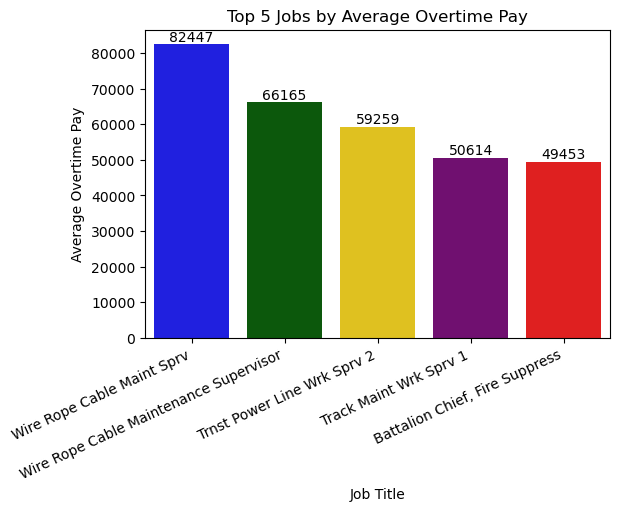

In [41]:
m=(df.groupby('JobTitle')['OvertimePay'].mean().sort_values(ascending=False).head(5)).reset_index()  

plt.figure(figsize=(6,4))

colors = ["blue", "darkgreen", "gold", "purple", "red"]


ax=sns.barplot(x='JobTitle', y='OvertimePay', data=m, hue='JobTitle', palette=colors)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
    
plt.xticks(rotation=25, ha='right')
plt.title('Top 5 Jobs by Average Overtime Pay')
plt.xlabel('Job Title')
plt.ylabel('Average Overtime Pay')
plt.show()

*What was the average (mean) BasePay of all employees per year? (2011-2014) ?*

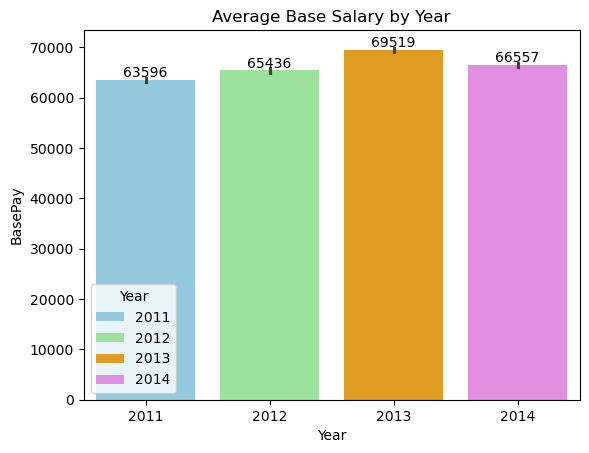

<Figure size 600x400 with 0 Axes>

In [42]:
colors = ["skyblue", "lightgreen", "orange", "violet"]

ax = sns.barplot(x='Year', y='BasePay',  hue= 'Year',data=df, palette=colors)

plt.title('Average Base Salary by Year')
plt.figure(figsize=(6, 4), dpi=100)  

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')   

plt.show()

*How are salaries distributed?*

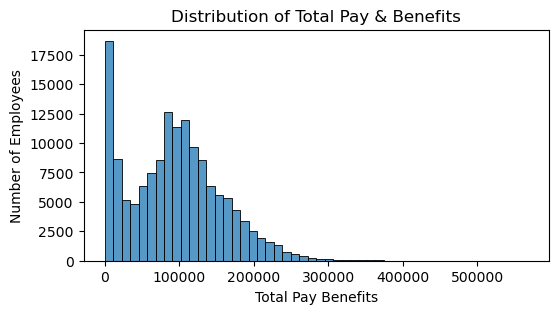

In [43]:
plt.figure(figsize=(6,3))

sns.histplot(
    df['TotalPayBenefits'],
    bins=50
)

plt.title("Distribution of Total Pay & Benefits")

plt.xlabel('Total Pay Benefits')
plt.ylabel('Number of Employees')
plt.show()

*Which job title has the maximum employees?*

In [44]:
df['JobTitle'].value_counts().head(5)

JobTitle
Transit Operator    9424
Special Nurse       5791
Registered Nurse    4955
Custodian           3214
Firefighter         3153
Name: count, dtype: int64

*Which employee has the highest Base Pay?*

In [45]:
df.sort_values('BasePay', ascending=False)[['Id','EmployeeName','BasePay']].head(5)

,Id,EmployeeName,BasePay
72925,72926,Gregory P Suhr,319275.01
110532,110533,Amy P Hart,318835.49
72929,72930,Robert L Shaw,315572.01
72926,72927,Joanne M Hayes-White,313686.01
72931,72932,Harlan L Kelly-Jr,313312.52


*Who are the highest-paid employees in each year (2011–2014)?*

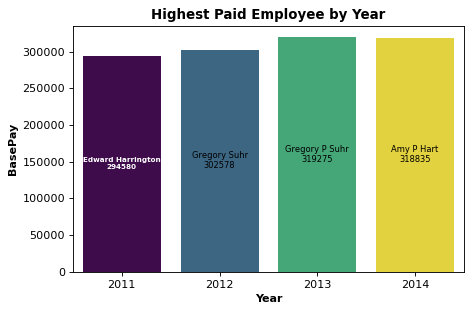

In [46]:

top_employee_per_year = df.loc[df.groupby('Year')['BasePay'].idxmax()].reset_index(drop=True)

plt.figure(figsize=(6,4),dpi=80)
sns.barplot(data=top_employee_per_year, x='Year', y='BasePay', hue='Year', legend=False, palette='viridis')

for index, row in top_employee_per_year.iterrows():
    if row['Year'] == 2011:
        plt.text(index, 
                 row['BasePay']/2,  
                 f"{row['EmployeeName']}\n{int(row['BasePay'])}", 
                 ha='center', va='center', fontsize=6.5, color='white', fontweight='bold')
    else:
        plt.text(index, 
                 row['BasePay']/2, 
                 f"{row['EmployeeName']}\n{int(row['BasePay'])}", 
                 ha='center', va='center', fontsize=7.5, color='black')



plt.title("Highest Paid Employee by Year" , fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("BasePay", fontweight='bold')
plt.tight_layout()
plt.show()


*How many employees did not receive any overtime pay?*

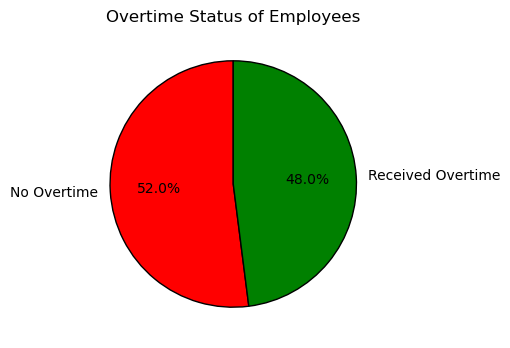

In [47]:


labels = ['No Overtime', 'Received Overtime']
values = [
    (df['OvertimePay'] == 0).sum(),
    (df['OvertimePay'] > 0).sum()
]
custom_colors = ['Red', 'Green']
plt.figure(figsize=(4,4),dpi=100)
plt.pie(values, labels=labels, autopct='%1.1f%%',colors= custom_colors ,startangle=90,wedgeprops={'edgecolor':'black','linewidth':1})
plt.title("Overtime Status of Employees")
plt.show()

*Who are the employees with exceptionally high total compensation?*

In [48]:
Q1 = df['TotalPayBenefits'].quantile(0.25)
Q3 = df['TotalPayBenefits'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    df['TotalPayBenefits']
    >
    (Q3 + 1.5*IQR)
]

print(
    outliers[
        ['EmployeeName',
         'JobTitle',
         'TotalPayBenefits']
    ].head(5)
)

        EmployeeName                                        JobTitle  \
0     Nathaniel Ford  General Manager-Metropolitan Transit Authority   
1       Gary Jimenez                 Captain Iii (Police Department)   
2     Albert Pardini                 Captain Iii (Police Department)   
3  Christopher Chong            Wire Rope Cable Maintenance Mechanic   
4    Patrick Gardner    Deputy Chief Of Department,(Fire Department)   

   TotalPayBenefits  
0         567595.43  
1         538909.28  
2         335279.91  
3         332343.61  
4         326373.19  


 *Who are the top 10 overtime earners?*

In [49]:
top_ot = df.nlargest(
    10,
    'OvertimePay'
)
print(top_ot[
    ['EmployeeName',
     'JobTitle',
     'OvertimePay']
])

              EmployeeName                         JobTitle  OvertimePay
1             Gary Jimenez  Captain Iii (Police Department)    245131.88
36159       Gary Altenberg     Lieutenant, Fire Suppression    220909.48
72964        Whitney P Yee                   Deputy Sheriff    196689.18
36163    Frederick Binkley        Emt/Paramedic/Firefighter    192424.49
110574  Antonio B Santiago                   Deputy Sheriff    173547.73
110577       Barry J Bloom                   Deputy Sheriff    173178.23
110583       Whitney P Yee                   Deputy Sheriff    169659.92
72943     Gary L Altenberg     Lieutenant, Fire Suppression    163477.81
36199       Scott Scholzen                      Firefighter    160418.47
73021        Barry J Bloom                   Deputy Sheriff    156077.49


*Which employees have the lowest Total Pay & Benefits?*

In [50]:
lowest_salary = df.nsmallest(10, 'TotalPayBenefits')
print(lowest_salary[['EmployeeName', 'JobTitle', 'TotalPayBenefits']])

                  EmployeeName                                    JobTitle  \
36156           Paulette Adams  Stationary Engineer, Water Treatment Plant   
36157            Kaukab Mohsin                            Transit Operator   
36158       Josephine Mccreary                                  Manager Iv   
148626           Paulet Gaines                               Account Clerk   
148627        Brett A Lundberg                             General Laborer   
148628          Mark W Mcclure                             General Laborer   
148629       Elizabeth Iniguez                          Transcriber Typist   
148630            Randy J Keys                                   Carpenter   
148631         Andre M Johnson                 Communications Dispatcher 1   
148632  Sharon D Owens-Webster                  Protective Services Worker   

        TotalPayBenefits  
36156                0.0  
36157                0.0  
36158                0.0  
148626               0.0  
148627

*Which employees have overtime pay lower than their benefits?*

In [51]:
over_time_Less_than = df[df['OvertimePay'] < df['Benefits']]
print(over_time_Less_than[['EmployeeName','JobTitle','OvertimePay','Benefits']].head(10))

             EmployeeName                     JobTitle  OvertimePay  Benefits
36160        Gregory Suhr              Chief Of Police         0.00  69810.19
36162  Joanne Hayes-White       Chief, Fire Department         0.00  72047.88
36164            Amy Hart                  Dept Head V         0.00  84681.82
36165      Edward Reiskin   Gen Mgr, Public Trnsp Dept         0.00  82001.94
36166         John Martin                  Dept Head V         0.00  81824.37
36167       John Goldberg                    Captain 3         0.00  24287.23
36173        Mark Kearney     Assistant Deputy Chief 2     22599.60  32381.00
36174         Leda Rozier            Transit Manager 2         0.00  60285.44
36175       Ellen Moffatt            Asst Med Examiner      3394.90  73017.12
36176      Raymond Guzman  Dep Chf Of Dept (Fire Dept)     24204.66  64702.72


*Which employees receive Benefits despite having zero Base Pay?*

In [52]:
Base_zero_base = df[(df['Benefits']>0) & (df['BasePay'] == 0)]
print(Base_zero_base[['EmployeeName','JobTitle','BasePay','Benefits']].head(10))

            EmployeeName                        JobTitle  BasePay  Benefits
39613    Frank Cardinale        Assistant Deputy Chief 2      0.0    189.79
40140    Michael Kearney  Battlion Chief, Fire Suppressi      0.0    216.65
46745    Gerald Scullion  Battlion Chief, Fire Suppressi      0.0   2083.86
54370     Ernest Wilberg                Police Officer 3      0.0    171.41
59341         David Seid                Police Officer 3      0.0    193.97
62721         Leslie Tom                Police Officer 3      0.0   1051.75
63159  Florencia Inserto    Physical Therapist Assistant      0.0  12095.95
63360   Lawrence Gray Jr                      Sergeant 3      0.0    108.55
64134             Van Ly       Attorney (Civil/Criminal)      0.0   3300.74
65390      Jensen Rhodes    Lieutenant, Fire Suppression      0.0    476.44


*Which employees receive Base Pay but no Benefits?*

In [53]:
benefit_zero_base = df[(df['Benefits'] ==0) & (df['BasePay'] >0)]
print(benefit_zero_base[['EmployeeName','JobTitle','BasePay','Benefits']].head(10))

         EmployeeName                                        JobTitle  \
0      Nathaniel Ford  General Manager-Metropolitan Transit Authority   
1        Gary Jimenez                 Captain Iii (Police Department)   
2      Albert Pardini                 Captain Iii (Police Department)   
3   Christopher Chong            Wire Rope Cable Maintenance Mechanic   
4     Patrick Gardner    Deputy Chief Of Department,(Fire Department)   
5      David Sullivan                       Assistant Deputy Chief Ii   
6           Alson Lee              Battalion Chief, (Fire Department)   
7       David Kushner                  Deputy Director Of Investments   
8      Michael Morris              Battalion Chief, (Fire Department)   
9  Joanne Hayes-White          Chief Of Department, (Fire Department)   

     BasePay  Benefits  
0  167411.18       0.0  
1  155966.02       0.0  
2  212739.13       0.0  
3   77916.00       0.0  
4  134401.60       0.0  
5  118602.00       0.0  
6   92492.01       0.

*Which employees receive Other Pay but no Overtime Pay?*

In [54]:
otherpay_no_ot = df[(df['OtherPay'] > 0) & (df['OvertimePay'] == 0)]
print(otherpay_no_ot[['EmployeeName','JobTitle','OtherPay','OvertimePay']].head(10))

          EmployeeName                                        JobTitle  \
0       Nathaniel Ford  General Manager-Metropolitan Transit Authority   
7        David Kushner                  Deputy Director Of Investments   
9   Joanne Hayes-White          Chief Of Department, (Fire Department)   
13         John Martin                               Department Head V   
16            Amy Hart                               Department Head V   
20          Venus Azar                      Assistant Medical Examiner   
25        Gregory Suhr                                 Chief Of Police   
28      Denise Schmitt            Deputy Chief Iii (Police Department)   
29       Monica Fields    Deputy Chief Of Department,(Fire Department)   
30     Harlan Kelly-Jr                     Executive Contract Employee   

     OtherPay  OvertimePay  
0   400184.25          0.0  
7    51322.50          0.0  
9    17115.73          0.0  
13   21342.59          0.0  
16   16115.86          0.0  
20   16679.